# Lotka-Volterra Model:

We will study the classic Lotka-Volterra model of competition between two species (rabbits and sheep).

$x(t) =$ population of rabbits

$y(t) =$ population of sheep

$$\dot{x} = x(3 - x - 2y)$$

$$\dot{y} = y(2 - x - y)$$

Both species are competing for the same food supply and the amount available is limited. We ignore predators, seasonal effects, and other sources of food. Then there are two main effects we should consider:

* 1. Each species would grow to its carrying capacity in the absence of the other (logistic growth for each species). Rabbits have a higher intrinsic growth rate.

* 2. We’ll assume that rabbit-sheep conflicts occur at a rate proportional to the size of each population, and we assume that the conflicts reduce the growth rate for each species, but the effect is more severe for the rabbits.

In [1]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

### Fixed points:

In [2]:
# Define symbols
x, y = sp.symbols("x y")

# Define the system
x_dot = x*(3. -x -2*y)
y_dot = y*(2. -x - y)

# Get the fixed points
fixed_points = sp.solve((x_dot, y_dot), (x, y))

print("The fixed points are:\n", fixed_points )

print("Fixed point 1:\n", fixed_points[0])
print("Fixed point 2:\n", fixed_points[1])
print("Fixed point 3:\n", fixed_points[2])
print("Fixed point 4:\n", fixed_points[3])

The fixed points are:
 [(0.0, 0.0), (0.0, 2.00000000000000), (1.00000000000000, 1.00000000000000), (3.00000000000000, 0.0)]
Fixed point 1:
 (0.0, 0.0)
Fixed point 2:
 (0.0, 2.00000000000000)
Fixed point 3:
 (1.00000000000000, 1.00000000000000)
Fixed point 4:
 (3.00000000000000, 0.0)


### Linearisation analysis:

In [3]:
# Jacobian matrix
F = sp.Matrix([x_dot, y_dot])
V = sp.Matrix([x,y])

# The Jacobian

J = F.jacobian(V)

display(J)

Matrix([
[-2*x - 2*y + 3.0,           -2*x],
[              -y, -x - 2*y + 2.0]])

In [4]:
# For loop
for fp in fixed_points:

    # Get the coordinates
    x_fp, y_fp = fp

    # Jacobian evaluation
    J_fp = J.subs({x: x_fp, y: y_fp})

    # Get eigenvalues
    eigv = J_fp.eigenvals()

    l_eig = np.array(list(eigv.keys()))

    print("Fixed points: ", fp)
    print("Eigenvalues: ", l_eig)

Fixed points:  (0.0, 0.0)
Eigenvalues:  [3.00000000000000 2.00000000000000]
Fixed points:  (0.0, 2.00000000000000)
Eigenvalues:  [-1.00000000000000 -2.00000000000000]
Fixed points:  (1.00000000000000, 1.00000000000000)
Eigenvalues:  [-2.41421356237309 0.414213562373095]
Fixed points:  (3.00000000000000, 0.0)
Eigenvalues:  [-3.00000000000000 -1.00000000000000]


### Phase diagram:

In [5]:
# Set the limits
x_min, x_max = -0.5, 3.5
y_min, y_max = -0.5, 3.

# Number of points
nx = ny = 40

# Generate the axes
x_1d = np.linspace(x_min, x_max, nx)
y_1d = np.linspace(x_min, x_max, ny)

# Meshgrid
x_2d, y_2d = np.meshgrid(x_1d, y_1d)

$$\dot{x} = x(3 - x - 2y)$$

$$\dot{y} = y(2 - x - y)$$

In [6]:
# Compute the velocity components
vx_2d = x_2d*(3. - x_2d - 2.*y_2d)
vy_2d = y_2d*(2. - x_2d - y_2d)

# Normalise to the magnitude
v_mag = np.sqrt(vx_2d**2 + vy_2d**2)

vx_2d = vx_2d/v_mag
vy_2d = vy_2d/v_mag

In [7]:
print(fixed_points[0])

(0.0, 0.0)


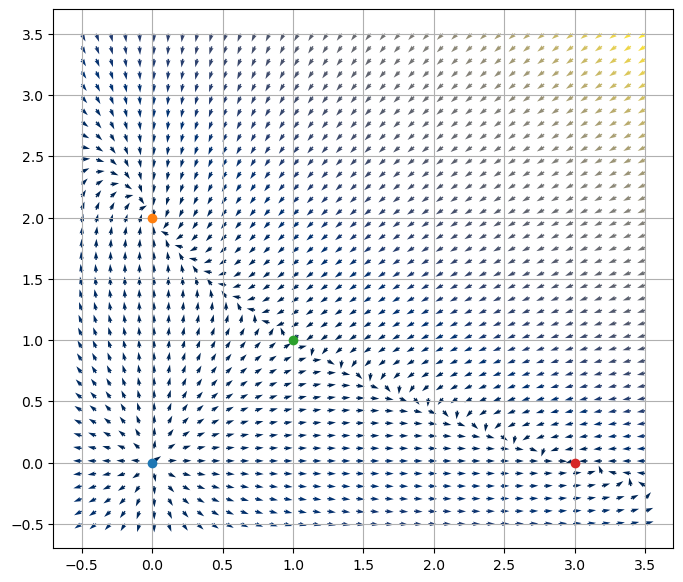

In [8]:
plt.figure(figsize = (8,7))

plt.quiver(x_2d, y_2d, vx_2d, vy_2d, v_mag, cmap = "cividis")

for k in range(len(fixed_points)):
    plt.plot(fixed_points[k][0], fixed_points[k][1], marker = "o", linestyle = " ")

plt.grid()
plt.show()

## Nullclines

$$y = 3/2 - x/2$$

$$y = 2 - x$$

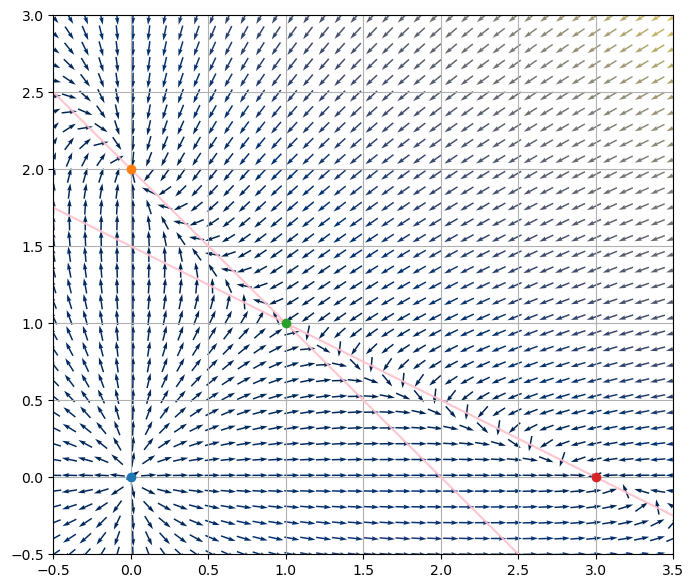

In [9]:
plt.figure(figsize = (8,7))

plt.plot(x_1d, 3./2. - x_1d/2., alpha = 0.9, color = "pink")
plt.plot(x_1d, 2. - x_1d, alpha = 0.9, color = "pink")

plt.quiver(x_2d, y_2d, vx_2d, vy_2d, v_mag, cmap = "cividis", scale=40, pivot='mid', linewidth=0.5)

for k in range(len(fixed_points)):
    plt.plot(fixed_points[k][0], fixed_points[k][1], marker = "o", linestyle = " ")


plt.xlim(-0.5, 3.5)
plt.ylim(-0.5, 3.0)

plt.grid()
plt.show()

### Numerical analysis:

In [10]:
import scipy as sc

In [21]:
# System Slope
def slope_function(t, state):
    """
    """
    # Unpack the state
    x, y = state 

    # Slopes
    dxt = x*(3. - x - 2.*y)
    dyt = y*(2. - x - y)

    return [dxt, dyt]

In [42]:
# Time axis
t_limits = [0., 5.]

# Number of steps
nt = 50

# Time axis
t_axis = np.linspace(t_limits[0], t_limits[1], nt)

# ICs
#ics = [[2., 0.25], [0.8, 2.0]]
n_ics = 10
ics = [[xx, yy] for xx in np.linspace(0.,+3,n_ics) for yy in np.linspace(0.,+3,n_ics)]

print(len(ics))

100


In [43]:
# Solve numerically

def compute_traj(ics_input):
    """
    """
    # Get ICs
    x0, y0 = ics_input

    # Forward in time integrator
    sln_f = sc.integrate.solve_ivp(slope_function, t_limits, [x0, y0], t_eval = t_axis, method = "RK45")

    # Backward in time integrator
    #sln_b = sc.integrate.solve_ivp(ode_system, t_backli, [x0, y0], t_eval = -t_axis, method = "RK45")
    
    return sln_f.y[0], sln_f.y[1]#, sln_b.y[0], sln_b.y[1]

In [44]:
# Empty list 
slns_f = []
#slns_b = []

# For loop to integrate all trajectories
# Integrate for ics
for ic in ics:
    x_t, y_t = compute_traj(ic)
    slns_f.append([x_t, y_t])
    #slns_b.append([x_nt, y_nt])

print(len(slns_f))#, len(slns_b))

100


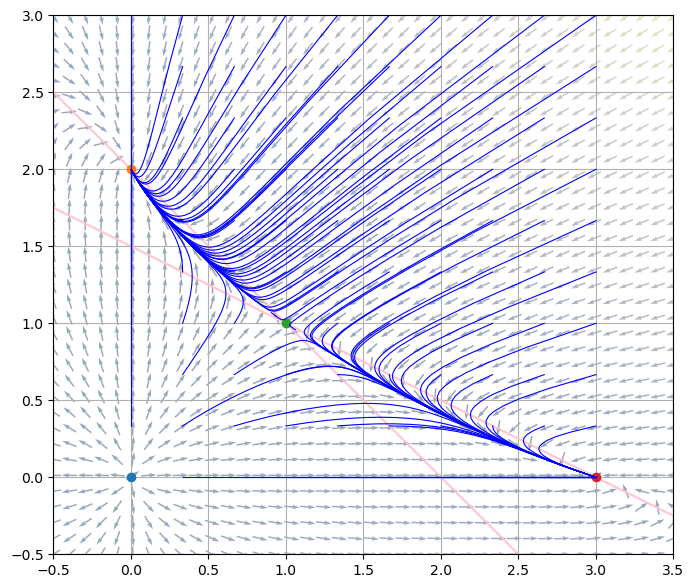

In [45]:
plt.figure(figsize = (8,7))

plt.plot(x_1d, 3./2. - x_1d/2., alpha = 0.9, color = "pink")
plt.plot(x_1d, 2. - x_1d, alpha = 0.9, color = "pink")

plt.quiver(x_2d, y_2d, vx_2d, vy_2d, v_mag, cmap = "cividis", scale=40, pivot='mid', linewidth=0.5, alpha = 0.4)

for k in range(len(fixed_points)):
    plt.plot(fixed_points[k][0], fixed_points[k][1], marker = "o", linestyle = " ")

# Add the trajectories
for j in range(len(slns_f)):
    #print(j)
    plt.plot(slns_f[j][0], slns_f[j][1], color = "blue", linestyle = "-", linewidth = 0.8)
    #plt.plot(slns_b[j][0], slns_b[j][1], color = "blue", linestyle = "-", linewidth = 0.5)


plt.xlim(-0.5, 3.5)
plt.ylim(-0.5, 3.0)

plt.grid()
plt.show()